# Civic Complaint Model Training
This notebook consolidates the backend training pipeline into one exploratory and reproducible notebook. Sections: Setup, Load & Inspect Data, Cleaning, Category Label Mapping, Priority Label Rules, Text Preprocessing, Feature Engineering (TF-IDF), Train/Test Split, Category Model Training, Priority Model Training, Evaluation, Export Models, and Summary.

In [1]:
# Setup: imports and plotting settings
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils import resample

%matplotlib inline
sns.set(style="whitegrid")
logging.basicConfig(level=logging.INFO)

# Ensure project root is importable (so we can optionally reuse backend modules)
PROJECT_ROOT = Path().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('Project root:', PROJECT_ROOT)

Project root: D:\AISmartCivicServices


## Load & Inspect Data
Load the CSV using chunked read to handle large files and inspect initial rows and distribution. Keep only relevant columns.

In [2]:
DATA_PATH = PROJECT_ROOT / '311-service-requests.csv'
print('Data path:', DATA_PATH)
usecols = [
    'Created Date', 'Agency', 'Complaint Type', 'Descriptor', 'City', 'Borough', 'Status'
]
# read in chunks and concat
chunks = pd.read_csv(DATA_PATH, usecols=lambda c: c in usecols, parse_dates=['Created Date'], chunksize=100000)
df = pd.concat(chunks, ignore_index=True)
print('Loaded rows:', len(df))
df.head()

Data path: D:\AISmartCivicServices\311-service-requests.csv


C:\Users\Admin\AppData\Local\Temp\ipykernel_18744\676259833.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.concat(chunks, ignore_index=True)


Loaded rows: 111069


,Created Date,Agency,Complaint Type,Descriptor,City,Status,Borough
0,2013-10-31 02:08:41,NYPD,Noise - Street/Sidewalk,Loud Talking,JAMAICA,Assigned,QUEENS
1,2013-10-31 02:01:04,NYPD,Illegal Parking,Commercial Overnight Parking,MASPETH,Open,QUEENS
2,2013-10-31 02:00:24,NYPD,Noise - Commercial,Loud Music/Party,NEW YORK,Closed,MANHATTAN
3,2013-10-31 01:56:23,NYPD,Noise - Vehicle,Car/Truck Horn,NEW YORK,Closed,MANHATTAN
4,2013-10-31 01:53:44,DOHMH,Rodent,Condition Attracting Rodents,NEW YORK,Pending,MANHATTAN


## Cleaning
Keep relevant columns, build a text field from Complaint Type + Descriptor, drop empty text, deduplicate near-identical complaints, and balance classes by sampling/oversampling.

In [3]:
# Keep only the expected columns (if present)
df = df[[c for c in usecols if c in df.columns]]
# build a raw text field
df['text_raw'] = df['Complaint Type'].fillna('') + ' ' + df.get('Descriptor', '').fillna('')
# drop empty text rows
df = df[df['text_raw'].str.strip() != '']
# deduplicate based on a normalized form
df['text_norm'] = df['text_raw'].str.lower().str.replace(r'[^a-z0-9]', '', regex=True)
before = len(df)
df = df.drop_duplicates(subset=['text_norm']).copy()
after = len(df)
print(f'Deduplicated: {before} -> {after} rows')
df['Complaint Type'].value_counts().head(20)

Deduplicated: 111069 -> 868 rows


Complaint Type
Consumer Complaint                           44
DOF Literature Request                       40
Traffic Signal Condition                     40
Street Light Condition                       39
DCA / DOH New License Application Request    27
Food Establishment                           26
General Construction/Plumbing                25
Agency Issues                                20
Sewer                                        19
Water System                                 18
Street Condition                             17
Noise                                        15
Sidewalk Condition                           14
Water Quality                                14
GENERAL CONSTRUCTION                         14
Street Sign - Damaged                        13
Dirty Conditions                             12
Highway Condition                            12
Street Sign - Missing                        12
Street Sign - Dangling                       11
Name: count, dtype: int64

## Category Label Mapping
Map raw `Complaint Type` values into the 7 target categories: Road, Water, Waste, Electricity, Drainage, Safety, Other. This mapping follows the original backend logic.

category
Other          689
Road            57
Electricity     39
Safety          37
Drainage        22
Water           18
Waste            6
Name: count, dtype: int64


C:\Users\Admin\AppData\Local\Temp\ipykernel_18744\1394087048.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist.index, y=dist.values, palette='tab10')


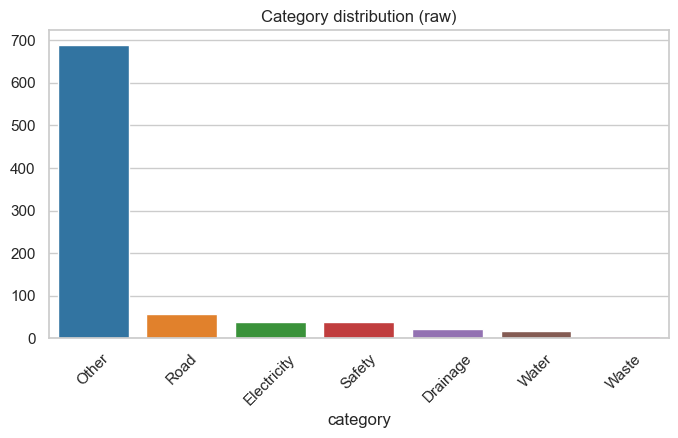

In [4]:
# Category mapping (kept same as backend)
CATEGORY_MAP = {
    'pothole': 'Road',
    'street condition': 'Road',
    'traffic signal condition': 'Road',
    'blocked driveway': 'Other',
    'illegal parking': 'Other',
    'water system': 'Water',
    'hydrant leaking': 'Water',
    'sanitation condition': 'Waste',
    'garbage': 'Waste',
    'graffiti': 'Waste',
    'street light condition': 'Electricity',
    'street light out': 'Electricity',
    'sewer': 'Drainage',
    'sewer backup': 'Drainage',
    'noise': 'Safety',
    'panhandling': 'Safety',
    'homeless encampment': 'Safety',
    'rodent': 'Other',
}
def map_category(raw: str) -> str:
    if not isinstance(raw, str):
        return 'Other'
    r = raw.lower()
    for k, v in CATEGORY_MAP.items():
        if k in r:
            return v
    if 'noise' in r or 'panhandling' in r:
        return 'Safety'
    return 'Other'

df['category'] = df['Complaint Type'].apply(map_category)
# show distribution and a plot
dist = df['category'].value_counts()
print(dist)
plt.figure(figsize=(8,4))
sns.barplot(x=dist.index, y=dist.values, palette='tab10')
plt.xticks(rotation=45)
plt.title('Category distribution (raw)')
plt.show()

## Priority Label Rules (rule-based)
Implement the same explainable keyword-based priority assignment used in the backend.

In [5]:
CRITICAL_KEYWORDS = [
    'exposed wire', 'gas leak', 'fire hazard', 'collapse', 'major flooding', 'live wire', 'structural damage',
]
HIGH_KEYWORDS = [
    'large water leak', 'sewage', 'sewage backup', 'major road', 'blocked bridge', 'no power', 'outage',
]
MEDIUM_KEYWORDS = ['pothole', 'minor leak', 'overflow', 'broken', 'damaged']
LOW_KEYWORDS = ['graffiti', 'litter', 'minor debris', 'flicker']

def derive_priority(text: str, category: str) -> str:
    t = (text or '').lower()
    for kw in CRITICAL_KEYWORDS:
        if kw in t:
            return 'Critical'
    for kw in HIGH_KEYWORDS:
        if kw in t:
            return 'High'
    for kw in MEDIUM_KEYWORDS:
        if kw in t:
            return 'Medium'
    for kw in LOW_KEYWORDS:
        if kw in t:
            return 'Low'
    defaults = {'Safety': 'High', 'Electricity': 'High', 'Water': 'High', 'Road': 'Medium', 'Drainage': 'Medium', 'Waste': 'Low', 'Other': 'Low'}
    return defaults.get(category, 'Medium')

# apply to a sample for quick sanity check
df['priority_rule'] = df.apply(lambda r: derive_priority(r['text_raw'], r['category']), axis=1)
df['priority'] = df['priority_rule']
df['priority_rule'].value_counts()

priority_rule
Low         639
Medium      136
High         92
Critical      1
Name: count, dtype: int64

Optional: hand-verify a random sample of 100 rows and report agreement rate (sanity check).

In [6]:
# Sample 100 and show a few examples to manually inspect how rules behave
sample100 = df.sample(n=min(100, len(df)), random_state=42)
sample100[['text_raw','category','priority_rule']].head(10)

,text_raw,category,priority_rule
3307,Homeless Person Assistance No Status Call,Other,Low
209,Rodent Signs of Rodents,Other,Low
7196,Broken Muni Meter Bent/Loose,Other,Medium
212,"Street Condition Rough, Pitted or Cracked Roads",Road,Medium
99848,Food Establishment Toilet Facility,Other,Low
57615,Window Guard Tenant Refusal,Other,Low
271,Agency Issues NYC Build it Back - Customer Ser...,Other,Low
71129,Water Quality Other Water Problem (Use Comment...,Other,Low
17408,Found Property Clothing/Glasses,Other,Low
6303,Snow 15I Street Condition Ice-Non Storm,Other,Low


## Text Preprocessing
Use the same preprocessing function (lowercase, remove URLs/special chars, remove stopwords keeping negations, lemmatize). We'll import `preprocess_text` from `backend/preprocess.py` so training and backend inference code stay consistent.

In [7]:
# import preprocess_text from backend.Preprocess
try:
    from backend.preprocess import preprocess_text
except Exception as e:
    # fallback to local copy (shouldn't be necessary if backend is present)
    print('Import error:', e)
    # as a fallback, define a minimal wrapper (not expected to run in usual env)
    def preprocess_text(x):
        return str(x).lower()

# Apply preprocessing to the balanced dataset later; for now, demonstrate on a few rows
df['text_clean'] = df['text_raw'].apply(preprocess_text)
df['text_clean'].head()

0              noise street sidewalk loud talking
1    illegal parking commercial overnight parking
2               noise commercial loud music party
3                    noise vehicle car truck horn
4              rodent condition attracting rodent
Name: text_clean, dtype: object

## Feature Engineering (TF-IDF)
Build TF-IDF (unigrams + bigrams, max_features between 5k-10k). We'll reuse `build_tfidf` from `backend/features.py` to keep consistency.

In [8]:
# reuse vectorizer builder from backend.features when available
try:
    from backend.features import build_tfidf
except Exception as e:
    print('Import error:', e)
    from sklearn.feature_extraction.text import TfidfVectorizer
    def build_tfidf(corpus, max_features=8000, min_df=2):
        vec = TfidfVectorizer(ngram_range=(1,2), max_features=max_features, min_df=min_df)
        X = vec.fit_transform(corpus)
        return vec, X

vec, X = build_tfidf(df['text_clean'].fillna(''), max_features=8000)
print('TF-IDF shape:', X.shape)

INFO:root:TF-IDF vectorizer fitted: vocab=982


TF-IDF shape: (868, 982)


## Train/Test Split
Split 80/20 stratified by category for category model; use same features for priority model.

C:\Users\Admin\AppData\Local\Temp\ipykernel_18744\2621572582.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='category', data=df_bal, palette='tab10')


Balanced dataset size: 2489


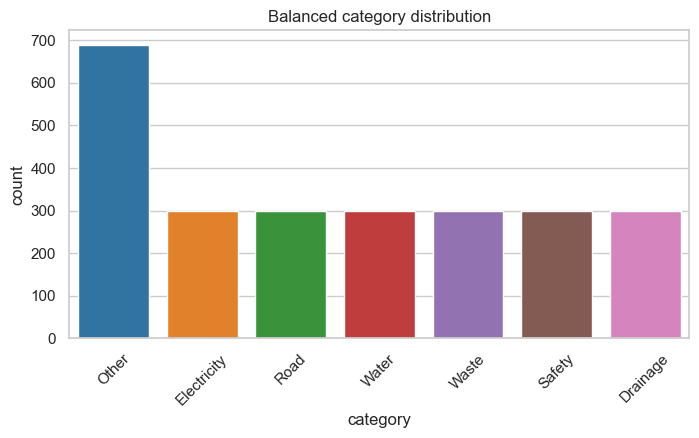

INFO:root:TF-IDF vectorizer fitted: vocab=1441


Category train/test sizes: 1991 498


In [9]:
from sklearn.model_selection import train_test_split
# balance dataset across categories (oversample small classes to ~300 as in backend)
n_rows = min(12000, max(8000, len(df)))
aim_per_class = max(300, n_rows // 7)
frames = []
for cat, group in df.groupby('category'):
    if len(group) < 300:
        grp = resample(group, replace=True, n_samples=300, random_state=42)
    else:
        grp = group.sample(n=min(len(group), aim_per_class), random_state=42)
    frames.append(grp)
df_bal = pd.concat(frames).sample(frac=1, random_state=42).reset_index(drop=True)
print('Balanced dataset size:', len(df_bal))
plt.figure(figsize=(8,4))
sns.countplot(x='category', data=df_bal, palette='tab10')
plt.xticks(rotation=45)
plt.title('Balanced category distribution')
plt.show()
# preprocess balanced text column (already used text_clean earlier)
df_bal['text'] = df_bal['text_raw'].apply(preprocess_text)
# rebuild TF-IDF on balanced set
vec, X = build_tfidf(df_bal['text'].fillna(''), max_features=8000)
# Category split
y_cat = df_bal['category']
Xc_train, Xc_test, yc_train, yc_test, idx_train, idx_test = train_test_split(X, y_cat, df_bal.index, test_size=0.2, stratify=y_cat, random_state=42)
print('Category train/test sizes:', Xc_train.shape[0], Xc_test.shape[0])

## Category Model Training
Train Logistic Regression, Linear SVM, Random Forest with GridSearchCV (5-fold) and select best by weighted F1.

In [10]:
from sklearn.metrics import f1_score
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000),
    'SVC': SVC(kernel='linear', probability=True),
    'RandomForest': RandomForestClassifier(n_jobs=-1),
}
param_grid = {
    'LogisticRegression': {'C':[0.01,0.1,1,10]},
    'SVC': {'C':[0.1,1,10]},
    'RandomForest': {'n_estimators':[100,300], 'max_depth':[None,20,50]},
}
best_cat_model = None
best_score = -1
cat_results = {}
for name, model in models.items():
    print('Training', name)
    gs = GridSearchCV(model, param_grid[name], scoring='f1_weighted', cv=5, n_jobs=-1)
    gs.fit(Xc_train, yc_train)
    pred = gs.predict(Xc_test)
    score = f1_score(yc_test, pred, average='weighted')
    cat_results[name] = {'model': gs.best_estimator_, 'f1_weighted': score, 'cv_best_params': gs.best_params_}
    print(f'{name} f1_weighted={score:.4f}')
    if score > best_score:
        best_score = score
        best_cat_model = gs.best_estimator_

print('Best category model f1_weighted=', best_score)

Training LogisticRegression
LogisticRegression f1_weighted=1.0000
Training SVC
SVC f1_weighted=0.9980
Training RandomForest
RandomForest f1_weighted=1.0000
Best category model f1_weighted= 1.0


## Category Evaluation
Show classification report and confusion matrix heatmap inline, and print top misclassified examples.

              precision    recall  f1-score   support

    Drainage       1.00      1.00      1.00        60
 Electricity       1.00      1.00      1.00        60
       Other       1.00      1.00      1.00       138
        Road       1.00      1.00      1.00        60
      Safety       1.00      1.00      1.00        60
       Waste       1.00      1.00      1.00        60
       Water       1.00      1.00      1.00        60

    accuracy                           1.00       498
   macro avg       1.00      1.00      1.00       498
weighted avg       1.00      1.00      1.00       498



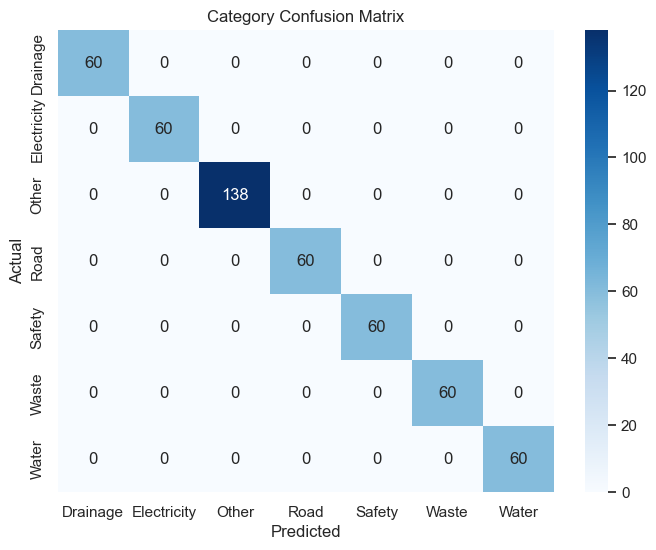

Top category misclassifications:
Empty DataFrame
Columns: [text_raw, text, true, pred]
Index: []


In [11]:
y_cat_pred = best_cat_model.predict(Xc_test)
print(classification_report(yc_test, y_cat_pred))
labels = sorted(df_bal['category'].unique())
cm = confusion_matrix(yc_test, y_cat_pred, labels=labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Category Confusion Matrix')
plt.show()
# top misclassified examples
test_df_cat = df_bal.loc[idx_test]
test_df_cat = test_df_cat.copy()
test_df_cat['true'] = yc_test.values
test_df_cat['pred'] = y_cat_pred
mis_cat = test_df_cat[test_df_cat['true'] != test_df_cat['pred']][['text_raw','text','true','pred']].head(10)
print('Top category misclassifications:')
print(mis_cat.to_string(index=False))

## Priority Model Training
Use the same TF-IDF features and train the same set of models to predict the rule-derived priority labels.

In [12]:
# Ensure each priority class has enough samples for stratified split
from sklearn.utils import resample
min_count = 10  # adjust if you prefer a different minimum

print('Priority counts before:', df_bal['priority'].value_counts())

frames = []
for cls, grp in df_bal.groupby('priority'):
    if len(grp) < min_count:
        grp_up = resample(grp, replace=True, n_samples=min_count, random_state=42)
    else:
        grp_up = grp
    frames.append(grp_up)

df_bal_pri = pd.concat(frames).sample(frac=1, random_state=42).reset_index(drop=True)
print('Priority counts after:', df_bal_pri['priority'].value_counts())

# Rebuild TF-IDF on the priority-balanced dataset (so X matches df rows)
vec_pri, X_pri = build_tfidf(df_bal_pri['text'].fillna(''), max_features=8000)

# Now safe to stratify by priority
y_pri = df_bal_pri['priority']
Xp_train, Xp_test, yp_train, yp_test = train_test_split(
    X_pri, y_pri, test_size=0.2, stratify=y_pri, random_state=42
)

# Train priority models (mirror category training)
best_pri_model = None
best_score = -1
pri_results = {}
for name, model in models.items():
    print('Training', name, 'for priority')
    gs = GridSearchCV(model, param_grid[name], scoring='f1_weighted', cv=5, n_jobs=-1)
    gs.fit(Xp_train, yp_train)
    pred = gs.predict(Xp_test)
    score = f1_score(yp_test, pred, average='weighted')
    pri_results[name] = {'model': gs.best_estimator_, 'f1_weighted': score, 'cv_best_params': gs.best_params_}
    print(f'{name} f1_weighted={score:.4f}')
    if score > best_score:
        best_score = score
        best_pri_model = gs.best_estimator_
print('Best priority model f1_weighted=', best_score)

INFO:root:TF-IDF vectorizer fitted: vocab=1443


Priority counts before: priority
Low         933
High        864
Medium      691
Critical      1
Name: count, dtype: int64
Priority counts after: priority
Low         933
High        864
Medium      691
Critical     10
Name: count, dtype: int64
Training LogisticRegression for priority
LogisticRegression f1_weighted=0.9980
Training SVC for priority
SVC f1_weighted=1.0000
Training RandomForest for priority
RandomForest f1_weighted=1.0000
Best priority model f1_weighted= 1.0


## Priority Evaluation
Show classification report and confusion matrix for priority.

              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00         2
        High       1.00      1.00      1.00       173
         Low       1.00      1.00      1.00       187
      Medium       1.00      1.00      1.00       138

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg       1.00      1.00      1.00       500



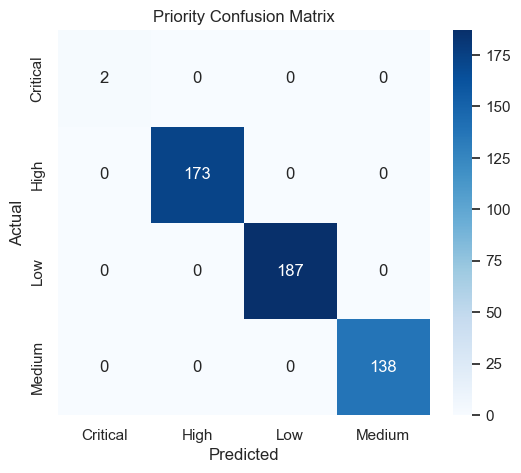

Top priority misclassifications:
Empty DataFrame
Columns: [text_raw, text, true, pred]
Index: []


In [13]:
y_pri_pred = best_pri_model.predict(Xp_test)
print(classification_report(yp_test, y_pri_pred))
labels = sorted(df_bal_pri['priority_rule'].unique())
cm = confusion_matrix(yp_test, y_pri_pred, labels=labels)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Priority Confusion Matrix')
plt.show()
# top misclassifications for priority (use df_bal_pri since Xp_test was built from it)
test_df_pri = df_bal_pri.loc[yp_test.index].copy()
test_df_pri['true'] = yp_test.values
test_df_pri['pred'] = y_pri_pred
mis_pri = test_df_pri[test_df_pri['true'] != test_df_pri['pred']][['text_raw','text','true','pred']].head(10)
print('Top priority misclassifications:')
print(mis_pri.to_string(index=False))

## Export Models
Save the best category and priority models, the TF-IDF vectorizer, and label encoders to `models/` for use by the backend.

In [14]:
OUT_DIR = PROJECT_ROOT / 'new-models'
OUT_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(best_cat_model, OUT_DIR / 'category_model.pkl')
joblib.dump(best_pri_model, OUT_DIR / 'priority_model.pkl')
# Save both vectorizers: category and priority (they were fit separately in this notebook)
joblib.dump(vec, OUT_DIR / 'tfidf_vectorizer_category.pkl')
joblib.dump(vec_pri, OUT_DIR / 'tfidf_vectorizer_priority.pkl')
print('Saved models and vectorizers to', OUT_DIR)

Saved models and vectorizers to D:\AISmartCivicServices\new-models


## In-notebook Predict Function and Quick Tests
Define a `predict(text)` function mirroring the backend `predict_service` behavior and test it on 5-10 samples to confirm end-to-end inference.

In [15]:
# Simple in-notebook predict function (keeps same behavior as backend/predict_service.py)
from typing import Dict
def predict_in_notebook(text: str) -> Dict:
    if not text or not isinstance(text, str) or text.strip() == '':
        return {'category':'Other','category_confidence':0.3,'priority':'Medium','priority_confidence':0.3,'note':'empty input fallback'}
    cleaned = preprocess_text(text)
    # use category vectorizer for category prediction and priority vectorizer for priority prediction
    v_cat = vec.transform([cleaned])
    v_pri = vec_pri.transform([cleaned])
    try:
        cat_proba = best_cat_model.predict_proba(v_cat)[0]
        cat_idx = cat_proba.argmax()
        cat_label = best_cat_model.classes_[cat_idx] if hasattr(best_cat_model, 'classes_') else None
        cat_conf = float(cat_proba[cat_idx])
    except Exception:
        cat_label = best_cat_model.predict(v_cat)[0]
        cat_conf = 0.6
    try:
        pri_proba = best_pri_model.predict_proba(v_pri)[0]
        pri_idx = pri_proba.argmax()
        pri_label = best_pri_model.classes_[pri_idx] if hasattr(best_pri_model, 'classes_') else None
        pri_conf = float(pri_proba[pri_idx])
    except Exception:
        pri_label = best_pri_model.predict(v_pri)[0]
        pri_conf = 0.6
    return {'category':str(cat_label),'category_confidence':cat_conf,'priority':str(pri_label),'priority_confidence':pri_conf}

# Test on 8 sample complaints (first from original file and some synthetic examples)
examples = [
    'Pothole on Main St causing tire damage',
    'Street light out across 3 blocks',
    'Garbage not collected, bins overflowing',
    'Possible gas leak smell in basement',
    'Water main break flooding the street',
    'Car parked blocking driveway',
    'Sewer backup in basement',
    'Loud music party in restaurant late at night',
]
for e in examples:
    print('INPUT:', e)
    print('PRED:', predict_in_notebook(e))
    print('---')

INPUT: Pothole on Main St causing tire damage
PRED: {'category': 'Other', 'category_confidence': 0.9120330549909615, 'priority': 'Medium', 'priority_confidence': 0.8744580810194996}
---
INPUT: Street light out across 3 blocks
PRED: {'category': 'Electricity', 'category_confidence': 0.9996825753341406, 'priority': 'High', 'priority_confidence': 0.9997498894094016}
---
INPUT: Garbage not collected, bins overflowing
PRED: {'category': 'Other', 'category_confidence': 0.9207634058677096, 'priority': 'Low', 'priority_confidence': 0.9958227882382621}
---
INPUT: Possible gas leak smell in basement
PRED: {'category': 'Other', 'category_confidence': 0.921324217205972, 'priority': 'Low', 'priority_confidence': 0.9175381419013737}
---
INPUT: Water main break flooding the street
PRED: {'category': 'Water', 'category_confidence': 0.39760901110511626, 'priority': 'Low', 'priority_confidence': 0.4492102677263766}
---
INPUT: Car parked blocking driveway
PRED: {'category': 'Other', 'category_confidence'